# XGBoost is an important machine-learning algorithm, especially for classification and regression problems

# 1. What is XGBoost?

* XGBoost = Extreme Gradient Boosting

* It is a tree-based ensemble machine-learning algorithm.

# The basic idea is:

#### Unlike a Random Forest, where many trees are generally built independently and combined, XGBoost builds trees sequentially, with later trees trying to correct errors made by previous trees.

# 2. Why do we use XGBoost?

* XGBoost is commonly used because it can work very well with:

* Numerical data
* Categorical data after encoding
* Classification
* Regression
* Large datasets
* Non-linear relationships
* Complex feature interactions
* Missing values in many practical workflows

# Example:

Suppose we want to predict whether a customer will leave:

# 3. Types of XGBoost

* There isn't a separate algorithm for every type; rather, XGBoost provides different learning objectives / estimator types.

* Type 1 — XGBClassifier

* Used for classification.

# Example:

In [9]:
from xgboost import XGBClassifier

model = XGBClassifier()

# Type 2 — XGBRegressor

* Used for regression.

# Example:

* House Price
* Salary
* Sales
* Temperature
* Revenue

In [14]:
from xgboost import XGBRegressor

model = XGBRegressor()

# Type 3 — Binary Classification

* Two classes.

* 0 = No
* 1 = Yes

# Example:

# Customer Churn
* 0 = Stay
* 1 = Leave

In [19]:
model = XGBClassifier(
    objective="binary:logistic"
)

# Type 4 — Multiclass Classification

* More than two classes.

# Example:

* 0 = Low
* 1 = Medium
* 2 = High

# Type 5 — Ranking

* XGBoost can also be used for ranking problems such as:

* Search results
* Recommendation systems
* Document ranking

# This is more advanced and uses ranking objectives such as rank:ndcg.

# 4. Important XGBoost Parameters

#### You will see these parameters frequently.

* n_estimators

# Number of trees.

* n_estimators=100

# More trees can improve learning, but too many can cause overfitting.

### learning_rate

* Controls how much each new tree contributes.

* learning_rate=0.1

# Small learning rate:

* 0.01
* 0.05
* 0.1

## Usually requires more trees.

### max_depth

* Maximum depth of each tree.

* max_depth=3

### Higher depth allows more complex trees but can increase overfitting.

## subsample

* Percentage of training rows used for each boosting step.

* subsample=0.8

### Means approximately 80% of rows are used.

### colsample_bytree

* Percentage of features used for each tree.

* colsample_bytree=0.8

# random_state

* Makes results reproducible.

* random_state=42

# 5. Complete XGBoost ML Workflow

* The complete workflow looks like this:

# 6. Step 1 — Problem Understanding

* First determine:

## What are we predicting?

## Example:

* Predict whether a customer will churn.
# What is X?

* Input/features:

* Age
* Income
* Tenure
* Monthly Charges
# What is y?

* Target:

* Churn

# 7. Step 2 — Import Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

| Library    | Purpose                   |
| ---------- | ------------------------- |
| pandas     | Data manipulation         |
| numpy      | Numerical operations      |
| matplotlib | Visualization             |
| seaborn    | Statistical visualization |
| xgboost    | XGBoost model             |
| sklearn    | Splitting and evaluation  |


# 8. Step 3 — Load Dataset

* For practice, let's create a dataset.

In [48]:
data = {
    "Age": [22, 25, 28, 30, 35, 40, 45, 50, 52, 55,
            24, 29, 33, 38, 42, 48, 51, 57, 60, 63],

    "Income": [25000, 30000, 35000, 40000, 45000,
               50000, 55000, 60000, 65000, 70000,
               28000, 36000, 42000, 48000, 52000,
               58000, 62000, 68000, 72000, 80000],

    "Tenure": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9,
               1, 3, 4, 5, 6, 7, 8, 9, 10, 11],

    "MonthlyCharges": [500, 550, 600, 650, 700,
                       750, 800, 850, 900, 950,
                       520, 620, 680, 720, 780,
                       820, 880, 920, 970, 1000],

    "Churn": [1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
              1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
}

df = pd.DataFrame(data)

print(df)

    Age  Income  Tenure  MonthlyCharges  Churn
0    22   25000       1             500      1
1    25   30000       2             550      1
2    28   35000       2             600      1
3    30   40000       3             650      1
4    35   45000       4             700      1
5    40   50000       5             750      0
6    45   55000       6             800      0
7    50   60000       7             850      0
8    52   65000       8             900      0
9    55   70000       9             950      0
10   24   28000       1             520      1
11   29   36000       3             620      1
12   33   42000       4             680      1
13   38   48000       5             720      0
14   42   52000       6             780      0
15   48   58000       7             820      0
16   51   62000       8             880      0
17   57   68000       9             920      0
18   60   72000      10             970      0
19   63   80000      11            1000      0


# 9. Step 4 — Understand Dataset

In [51]:
print(df.head())

   Age  Income  Tenure  MonthlyCharges  Churn
0   22   25000       1             500      1
1   25   30000       2             550      1
2   28   35000       2             600      1
3   30   40000       3             650      1
4   35   45000       4             700      1


In [53]:
print(df.shape)

(20, 5)


In [55]:
print(df.columns)

Index(['Age', 'Income', 'Tenure', 'MonthlyCharges', 'Churn'], dtype='object')


In [57]:
print(df.dtypes)

Age               int64
Income            int64
Tenure            int64
MonthlyCharges    int64
Churn             int64
dtype: object


In [59]:
print(df.describe())

             Age        Income     Tenure  MonthlyCharges      Churn
count  20.000000     20.000000  20.000000       20.000000  20.000000
mean   41.350000  51050.000000   5.550000      758.000000   0.400000
std    12.799157  15846.218211   3.034451      153.780431   0.502625
min    22.000000  25000.000000   1.000000      500.000000   0.000000
25%    29.750000  39000.000000   3.000000      642.500000   0.000000
50%    41.000000  51000.000000   5.500000      765.000000   0.000000
75%    51.250000  62750.000000   8.000000      885.000000   1.000000
max    63.000000  80000.000000  11.000000     1000.000000   1.000000


In [61]:
print(df.isnull().sum())

Age               0
Income            0
Tenure            0
MonthlyCharges    0
Churn             0
dtype: int64


# 10. Step 5 — Data Cleaning

* Check duplicate rows:

In [64]:
print(df.duplicated().sum())

0


In [66]:
df = df.drop_duplicates()

In [68]:
print(df.isnull().sum())

Age               0
Income            0
Tenure            0
MonthlyCharges    0
Churn             0
dtype: int64


In [70]:
df["Age"] = df["Age"].fillna(df["Age"].median())

# 11. Step 6 — EDA

* Let's understand the target.

In [77]:
print(df["Churn"].value_counts())

Churn
0    12
1     8
Name: count, dtype: int64


In [79]:
print(df["Churn"].value_counts(normalize=True))# This tells us the proportion of each class.

Churn
0    0.6
1    0.4
Name: proportion, dtype: float64


# 12. Step 7 — Data Visualization
* Histogram

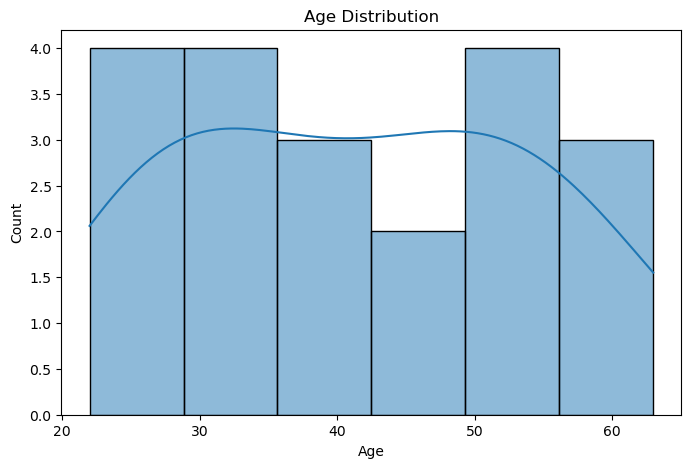

In [82]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    kde=True
)

plt.title("Age Distribution")
plt.show()

In [84]:
# This helps us understand the distribution of age.

#  Boxplot

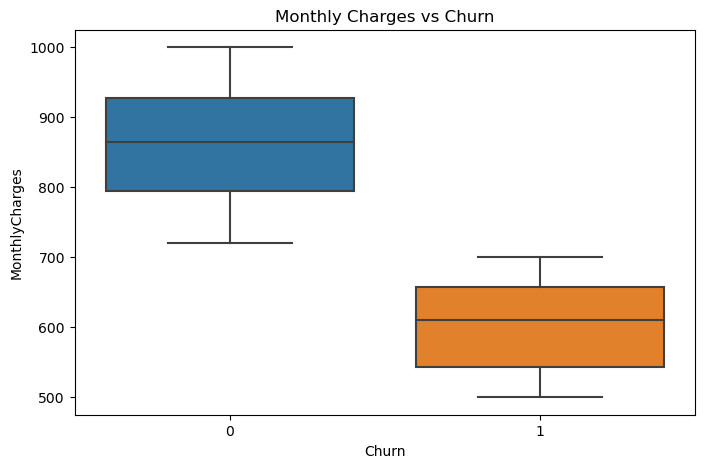

In [87]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

# Scatter plot

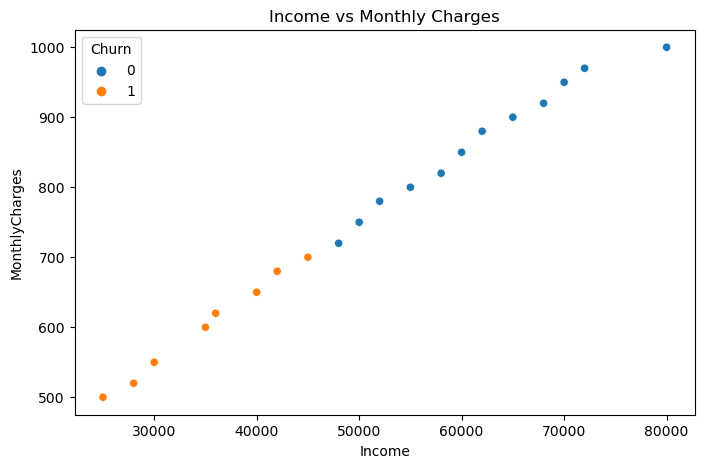

In [90]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Income",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Income vs Monthly Charges")
plt.show()

# Correlation heatmap

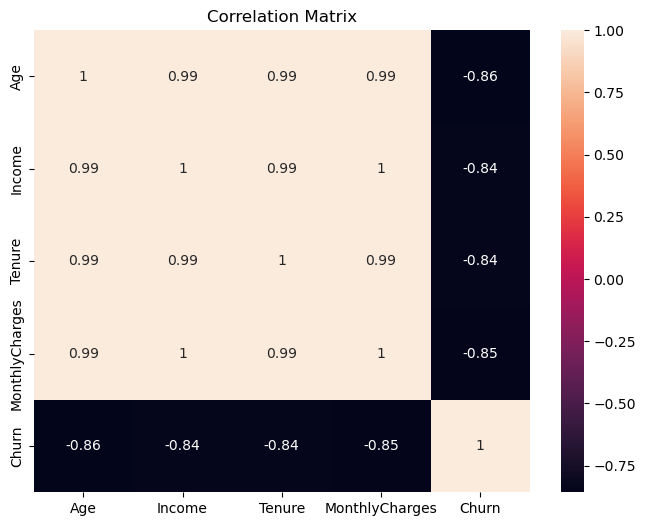

In [96]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

# 13. Step 8 — Feature and Target Separation

* This is extremely important.

In [99]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

# 14. Step 9 — Train/Test Split

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 15. Step 10 — Build XGBoost Model

In [105]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

# 16. Step 11 — Train the Model

In [108]:
model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

# 17. Step 12 — Prediction

In [111]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 1 0]


# 18. Step 13 — Model Evaluation
* Accuracy

In [114]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 1.0


# Confusion Matrix

In [117]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[2 0]
 [0 2]]


# Visualize it:

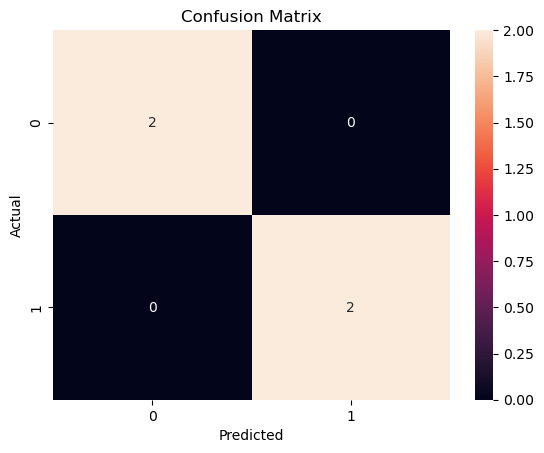

In [120]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report

In [123]:
print(
    classification_report(
        y_test,
        y_pred
    )
)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



# 19. Step 14 — Feature Importance

* One of the useful features of tree-based models is that we can inspect feature importan

In [126]:
importance = model.feature_importances_

feature_names = X.columns

for feature, value in zip(
    feature_names,
    importance
):
    print(feature, value)

Age 1.0
Income 0.0
Tenure 0.0
MonthlyCharges 0.0


# Visualization

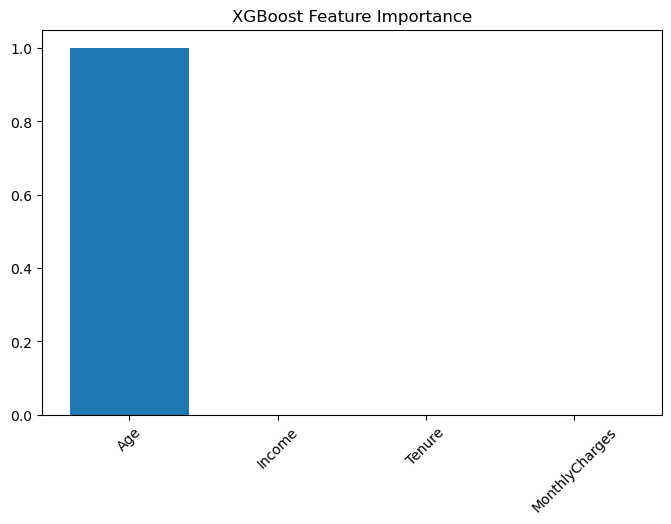

In [129]:
plt.figure(figsize=(8, 5))

plt.bar(
    X.columns,
    model.feature_importances_
)

plt.xticks(rotation=45)

plt.title("XGBoost Feature Importance")

plt.show()

## This helps answer:

* Which features contributed most to the model's predictions according to this feature-importance measure?

# 20. Example 1 — Customer Churn Classification

* This is the complete example we just created.

# Problem

* A telecom company wants to predict whether a customer will leave.

### Features:

* Age
* Income
* Tenure
* MonthlyCharges

### Target

* Churn

# Model:

* XGBClassifier()

# 21. Example 2 — House Price Prediction

* Here XGBoost becomes a regression model.

# Problem Statement

* A real-estate company wants to predict house prices.

# Features:

* Area
* Bedrooms
* Bathrooms
* Age
* Parking

# Target:

* Price

In [137]:
import pandas as pd

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = {
    "Area": [800, 1000, 1200, 1500, 1800,
             2000, 2200, 2500, 2800, 3000],

    "Bedrooms": [2, 2, 3, 3, 3,
                 4, 4, 4, 5, 5],

    "Bathrooms": [1, 2, 2, 2, 3,
                  3, 3, 4, 4, 4],

    "Age": [20, 15, 12, 10, 8,
            7, 5, 4, 3, 2],

    "Parking": [0, 1, 1, 1, 2,
                2, 2, 2, 3, 3],

    "Price": [3000000, 3800000, 4500000, 5500000,
              6500000, 7500000, 8500000, 9500000,
              11000000, 12500000]
}

In [139]:
df = pd.DataFrame(data)

X = df.drop("Price", axis=1)
y = df["Price"]

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [143]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [145]:
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [147]:
y_pred = model.predict(X_test)


In [149]:
print("MAE:",
      mean_absolute_error(y_test, y_pred))

print("RMSE:",
      mean_squared_error(y_test, y_pred) ** 0.5)

print("R2 Score:",
      r2_score(y_test, y_pred))

MAE: 1141050.0
RMSE: 1198479.5667432132
R2 Score: 0.8891702722298611


# Important difference

#### Classification:

* XGBClassifier()

### Regression:

* XGBRegressor()

# 22. Example 3 — Student Pass/Fail Prediction
### Problem

* Predict whether a student will pass.

## Features:

* Study Hours
* Attendance
* Previous Score
* Assignments Completed

## Target:

* Pass

In [153]:
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [155]:
data = {
    "Study_Hours": [1,2,2,3,3,4,4,5,5,6,
                    1,2,3,4,5],

    "Attendance": [50,55,60,65,70,75,80,85,90,95,
                   52,62,68,78,88],

    "Previous_Score": [40,45,48,52,55,60,65,70,75,80,
                       42,47,53,63,72],

    "Assignments": [2,3,3,4,5,5,6,7,8,9,
                    2,3,4,6,8],

    "Pass": [0,0,0,0,1,1,1,1,1,1,
             0,0,1,1,1]
}


In [157]:
df = pd.DataFrame(data)

In [159]:
X = df.drop("Pass", axis=1)
y = df["Pass"]

In [161]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [163]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

In [165]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [167]:
y_pred = model.predict(X_test)

In [169]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))


Accuracy: 0.6666666666666666


In [171]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



C:\Users\ipcs nagpur\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ipcs nagpur\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ipcs nagpur\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# 23. Example 4 — Diabetes Prediction

* This is a very common classification problem.

# Problem

* Predict whether a patient has diabetes based on selected measurements.

# Features:

* Age
* BMI
* Blood Glucose
* HbA1c
* Hypertension
* Heart Disease

# Target:

* Diabetes

In [174]:
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

data = {
    "Age": [25,30,35,40,45,50,55,60,65,70,
            28,34,42,48,58],

    "BMI": [22,24,26,28,30,32,34,35,31,33,
            23,27,29,31,36],

    "Blood_Glucose": [90,95,100,110,120,130,140,150,160,170,
                      92,105,115,125,145],

    "HbA1c": [4.8,5.0,5.2,5.5,5.8,6.0,6.2,6.5,6.8,7.0,
              4.9,5.3,5.6,6.1,6.4],

    "Hypertension": [0,0,0,0,1,1,1,1,1,1,
                     0,0,0,1,1],

    "Heart_Disease": [0,0,0,0,0,0,1,1,1,1,
                      0,0,0,0,1],

    "Diabetes": [0,0,0,0,0,1,1,1,1,1,
                 0,0,0,1,1]
}

df = pd.DataFrame(data)


In [176]:
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [178]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [180]:
y_pred = model.predict(X_test)

In [182]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



# 24. Example 5 — Sales Prediction

* Here we use XGBoost for regression.

# Problem

* A company wants to predict monthly sales.

# Features:

* Advertising
* Number of Customers
* Discount
* Previous Sales

# Target:

* Sales

In [185]:
import pandas as pd

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

data = {
    "Advertising": [10,20,30,40,50,60,70,80,90,100,
                    15,35,45,65,85],

    "Customers": [100,150,200,250,300,350,400,450,500,550,
                  120,220,280,380,480],

    "Discount": [5,5,10,10,15,15,20,20,25,25,
                 5,10,10,15,20],

    "Previous_Sales": [1000,1200,1500,1800,2200,
                       2500,2800,3200,3500,4000,
                       1100,1600,2000,2700,3400],

    "Sales": [1100,1350,1700,2050,2500,
              2850,3200,3650,4000,4500,
              1250,1800,2250,3050,3900]
}

df = pd.DataFrame(data)

In [187]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:",
      mean_absolute_error(y_test, y_pred))

print("R2 Score:",
      r2_score(y_test, y_pred))

MAE: 301.414306640625
R2 Score: 0.9371630045340529


# 25. Visualization for Regression

* After prediction, compare actual and predicted values.

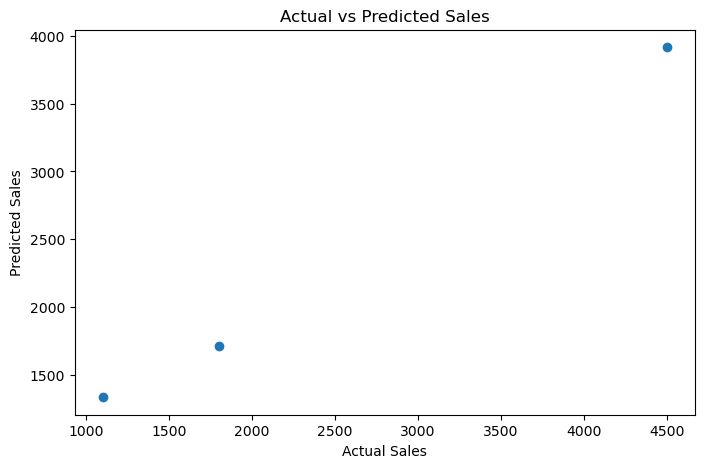

In [190]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()

A prediction closer to the diagonal relationship generally indicates closer agreement between actual and predicted values.

# 26. Cross Validation

* A single train/test split can give a result that depends on how the data happened to be divided.

* We can use cross-validation.

In [194]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("CV Scores:", scores)
print("Average CV Score:", scores.mean())

CV Scores: [-2.57384246e-04 -4.71434336e-01 -3.79925333e-01  9.41933079e-01
  8.86780598e-01]
Average CV Score: 0.1954193248933633


# 27. Hyperparameter Tuning

* XGBoost has many parameters.

# For example:

In [197]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.1, 0.2]
}

Use GridSearchCV:

In [216]:
# from sklearn.model_selection import GridSearchCV

# model = XGBClassifier(
#     random_state=42,
#     eval_metric="logloss"
# )

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=5,
#     scoring="accuracy",
#     n_jobs=-1
# )

# grid_search.fit(X_train, y_train)

# print("Best Parameters:")
# print(grid_search.best_params_)

# print("Best Score:")
# print(grid_search.best_score_)

In [214]:
# # Then obtain the best model:

# best_model = grid_search.best_estimator_

In [212]:
import pandas as pd
from xgboost import XGBRegressor  # Keep it consistent for regression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare Data
data = {
    "Advertising": [10,20,30,40,50,60,70,80,90,100, 15,35,45,65,85],
    "Customers": [100,150,200,250,300,350,400,450,500,550, 120,220,280,380,480],
    "Discount": [5,5,10,10,15,15,20,20,25,25, 5,10,10,15,20],
    "Previous_Sales": [1000,1200,1500,1800,2200, 2500,2800,3200,3500,4000, 1100,1600,2000,2700,3400],
    "Sales": [1100,1350,1700,2050,2500, 2850,3200,3650,4000,4500, 1250,1800,2250,3050,3900]
}

df = pd.DataFrame(data)

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Initial Model Training & Evaluation
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("--- Initial Evaluation ---")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# 3. Cross-Validation
scores = cross_val_score(
    model, X, y, cv=5, scoring="r2"
)
print("\n--- Cross-Validation ---")
print("CV Scores:", scores)
print("Average CV Score:", scores.mean())

# 4. Hyperparameter Tuning (Grid Search)
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.1, 0.2]
}

# FIX: Switched from XGBClassifier to XGBRegressor
tuning_model = XGBRegressor(
    random_state=42
)

# FIX: Changed scoring metric from 'accuracy' to 'r2' for regression
grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n--- Hyperparameter Tuning ---")
print("Best Parameters:", grid_search.best_params_)
print("Best Score (R2):", grid_search.best_score_)

best_model = grid_search.best_estimator_


--- Initial Evaluation ---
MAE: 301.414306640625
R2 Score: 0.9371630045340529

--- Cross-Validation ---
CV Scores: [-2.57384246e-04 -4.71434336e-01 -3.79925333e-01  9.41933079e-01
  8.86780598e-01]
Average CV Score: 0.1954193248933633

--- Hyperparameter Tuning ---
Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best Score (R2): 0.7263695993650992


In [206]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=2,  # Reduced from 5 to 2 (requires at least 2 samples per class)
    scoring="accuracy",
    n_jobs=-1
)

In [218]:
# 28. Important XGBoost Parameters to Practice

### Start with these:

# XGBClassifier(
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=3,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )



# 29. Do We Need Feature Scaling?

* This is an important difference from algorithms such as KNN or logistic regression.

* For standard tree-based XGBoost workflows, feature scaling is generally not required.

# For example, you can have:

* Age          → 25
* Income       → 50000
* Experience   → 5

## without necessarily doing:

* StandardScaler()

## before XGBoost.

* However, encoding categorical variables correctly is still important.

# 30. XGBoost with Categorical Variables

# 31. XGBoost vs Random Forest

| Feature             | Random Forest       | XGBoost                 |
| ------------------- | ------------------- | ----------------------- |
| Basic idea          | Bagging             | Boosting                |
| Trees               | Usually independent | Sequential              |
| Main goal           | Reduce variance     | Correct previous errors |
| Classification      | Yes                 | Yes                     |
| Regression          | Yes                 | Yes                     |
| Non-linear data     | Good                | Good                    |
| Feature importance  | Yes                 | Yes                     |
| Hyperparameters     | Many                | Many                    |
| Training complexity | Usually simpler     | More tuning required    |


# 32. Complete Project Architecture

* For your ML projects, I recommend remembering this structure:

# 33. Five XGBoost Projects to Practice

* You can practice these in this order:

| # | Project             | Type           | Model           |
| - | ------------------- | -------------- | --------------- |
| 1 | Customer Churn      | Classification | `XGBClassifier` |
| 2 | House Price         | Regression     | `XGBRegressor`  |
| 3 | Student Pass/Fail   | Classification | `XGBClassifier` |
| 4 | Diabetes Prediction | Classification | `XGBClassifier` |
| 5 | Sales Prediction    | Regression     | `XGBRegressor`  |
